In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('data/Hale.csv')
data.head()

,wl,n
0,0.200,1.396
1,0.225,1.373
2,0.250,1.362
3,0.275,1.354
4,0.300,1.349


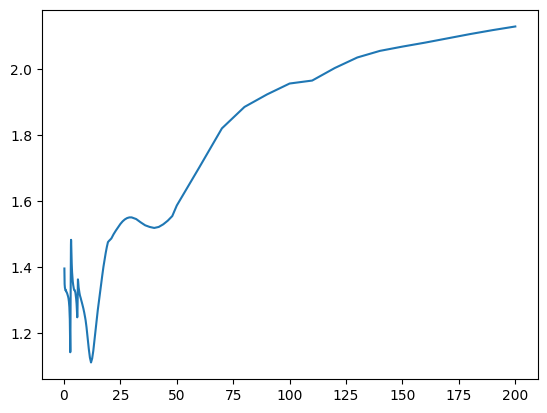

In [2]:
plt.plot(data['wl'], data['n'])

In [3]:
import numpy as np
import pandas as pd
import os

# -------------------- НАСТРОЙКИ --------------------
hale_path = "data/Hale.csv"               # wl column MUST be in microns (µm)
estar_path = "data/ESTAR_pos_water.txt"   # optional: T_MeV, S_total_MeV_per_cm or CSDA_range_cm
T0_MeV = 6.0
E_min_MeV = 1e-3
dE_MeV = 0.002
# --------------------------------------------------

# constants
alpha = 1.0/137.035999084
m_e_MeV = 0.5109989461

# Совместимость с разными версиями NumPy: используем trapezoid вместо trapz
if hasattr(np, 'trapezoid'):
    custom_trapz = np.trapezoid  # Для новых версий NumPy (>=1.20.0)
else:
    custom_trapz = np.trapz      # Для старых версий (без предупреждений)

# ---- Read Hale.csv (FORCE µm -> meters) ----
def read_hale_microns(path):
    df = pd.read_csv(path)
    if 'wl' not in df.columns or 'n' not in df.columns:
        raise RuntimeError("Hale.csv must contain columns 'wl' and 'n'")
    wl_microns = np.array(df['wl'], dtype=float)   # <-- ASSUME microns
    n_vals = np.array(df['n'], dtype=float)
    wl_m = wl_microns * 1e-6                        # µm -> m
    order = np.argsort(wl_m)
    return wl_m[order], n_vals[order], wl_microns[order]

# ---- ESTAR: read S(T) or fallback approximate realistic table ----
def read_estar_if_exists(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, sep='|', header=0)
    # print(df.head())
    if 'T_MeV' not in df.columns:
        raise RuntimeError("ESTAR file must have 'T_MeV' column")
    # if 'S_total_MeV_per_cm' in df.columns:
    #     T = np.array(df['T_MeV'], dtype=float)
    #     S = np.array(df['S_total_MeV_per_cm'], dtype=float)
    #     order = np.argsort(T)
    #     return ('S_vs_T', T[order], S[order])
    if 'CSDA_range_cm' in df.columns:
        T = np.array(df['T_MeV'], dtype=float)
        R = np.array(df['CSDA_range_cm'], dtype=float)
        order = np.argsort(T)
        R_sorted = R[order]
        T_sorted = T[order]
        # dR/dT -> S = 1 / (dR/dT) where R in cm, T in MeV -> S MeV/cm
        dR_dT = np.gradient(R_sorted, T_sorted)
        dR_dT_safe = np.where(np.abs(dR_dT) < 1e-12, 1e-12, dR_dT)
        S = 1.0 / dR_dT_safe
        return ('S_vs_T', T_sorted, S)
    raise RuntimeError("ESTAR must contain 'S_total_MeV_per_cm' or 'CSDA_range_cm'")

def build_S_func(estar_tuple):
    if estar_tuple is None:
        # realistic approximate stopping-power table (MeV/cm) for electrons/positrons in water (order-of-magnitude, NIST-like)
        T_tab = np.array([0.01, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0])
        S_tab = np.array([50.0, 13.0, 4.6, 3.05, 2.28, 2.05, 1.97, 1.94, 1.92, 1.89, 1.88])
        def S_of_T(Tq):
            Tq = np.atleast_1d(Tq)
            return np.interp(Tq, T_tab, S_tab, left=S_tab[0], right=S_tab[-1])
        print("NOTICE: ESTAR not found — using built-in ESTAR-like S(T) (MeV/cm). Replace with NIST table for high accuracy.")
        return S_of_T
    else:
        _, T_tab, S_tab = estar_tuple
        def S_of_T(Tq):
            Tq = np.atleast_1d(Tq)
            return np.interp(Tq, T_tab, S_tab, left=S_tab[0], right=S_tab[-1])
        print("Using ESTAR-provided S(T).")
        return S_of_T

# ---- beta(T) ----
def beta_from_T(T):
    T = np.array(T, dtype=float)
    E_tot = T + m_e_MeV
    gamma = E_tot / m_e_MeV
    beta2 = 1.0 - 1.0/(gamma*gamma)
    return np.sqrt(np.clip(beta2, 0.0, 1.0))

# ---- Frank–Tamm integrand vectorized ----
# inputs:
#   beta: scalar
#   n_array: array at lam grid
#   lam_array: array (meters)
# returns array shape lam_array: d2N/(dx dλ) in units photons / (m * m)
def d2N_dx_dlambda(beta, n_array, lam_array):
    b = float(beta)
    arg = b * n_array
    mask = arg > 1.0
    res = np.zeros_like(lam_array, dtype=float)
    if not np.any(mask):
        return res
    lam2 = lam_array[mask]**2
    b2 = b*b
    res[mask] = 2.0 * np.pi * alpha / lam2 * (1.0 - 1.0/(b2 * (n_array[mask]**2)))
    return res

# ---- robust find lambda_th by interpolation (handles monotonic n(λ) up or down) ----
def find_lambda_th(b, lam_m, n_vals):
    target = 1.0 / b
    # no emission anywhere
    if np.all(n_vals < target):
        return np.nan
    # emission at all wavelengths in grid
    if np.all(n_vals >= target):
        return lam_m[-1]
    # try to detect monotonicity
    diffs = np.diff(n_vals)
    if np.all(diffs <= 0):  # monotonic decreasing
        # interpolate target vs n_vals[::-1] to make x increasing
        lam_th = np.interp(target, n_vals[::-1], lam_m[::-1], left=np.nan, right=np.nan)
        return lam_th
    if np.all(diffs >= 0):  # monotonic increasing
        lam_th = np.interp(target, n_vals, lam_m, left=np.nan, right=np.nan)
        return lam_th
    # non-monotonic: find first sign change of (n-target)
    s = n_vals - target
    idx = np.where(s[:-1] * s[1:] <= 0)[0]  # indices where sign changes or zero crossing
    if idx.size == 0:
        return np.nan
    i = idx[0]
    x0, x1 = lam_m[i], lam_m[i+1]
    y0, y1 = n_vals[i], n_vals[i+1]
    if y1 == y0:
        return x0
    frac = (target - y0) / (y1 - y0)
    return x0 + frac*(x1 - x0)

# ---- main compute ----
def compute(hale_path, estar_path, T0, E_min, dE):
    lam_m, n_vals, wl_microns = read_hale_microns(hale_path)   # lam_m in meters
    lam_nm = lam_m * 1e9
    print(f"Assumed wl units: microns. wl range = {lam_nm.min():.1f} nm .. {lam_nm.max():.1f} nm")

    estar_tuple = read_estar_if_exists(estar_path) if os.path.exists(estar_path) else None
    S_func = build_S_func(estar_tuple)   # S in MeV/cm

    # energy grid
    T_grid = np.arange(E_min, T0 + 1e-12, dE)
    beta_grid = beta_from_T(T_grid)

    # vectorized integrand I(E) = ∫ dλ d2N/dx/dλ (photons per m)
    N_T = T_grid.size
    N_l = lam_m.size
    mem_mb = N_T * N_l * 8 / 1024**2
    I_vals = np.zeros_like(T_grid)

    if mem_mb < 4000:
        B = beta_grid[:, None]        # (N_T,1)
        Nmat = n_vals[None, :]        # (1, N_l)
        Lam = lam_m[None, :]          # (1, N_l)
        cond = (B * Nmat) > 1.0
        denom = np.where(cond, (B*B) * (Nmat*Nmat), 1.0)
        integrand = np.where(cond, 2.0*np.pi*alpha / (Lam*Lam) * (1.0 - 1.0/denom), 0.0)
        # integrate over lambda (meters) -> photons per meter
        I_vals = custom_trapz(integrand, x=lam_m, axis=1)  # Используем custom_trapz
    else:
        for i, b in enumerate(beta_grid):
            integrand_i = d2N_dx_dlambda(b, n_vals, lam_m)
            I_vals[i] = custom_trapz(integrand_i, lam_m)  # Используем custom_trapz

    # S(E) MeV/cm -> MeV/m
    S_vals_MeV_per_cm = S_func(T_grid)
    S_vals_MeV_per_m = S_vals_MeV_per_cm * 100.0
    S_vals_MeV_per_m = np.where(S_vals_MeV_per_m <= 0, 1e-12, S_vals_MeV_per_m)

    # integrand over energy: I(E) [photons/m] / S(E) [MeV/m] -> photons/MeV; integrate dE (MeV) -> photons
    integrand_E = I_vals / S_vals_MeV_per_m   # photons per MeV
    N_total = custom_trapz(integrand_E, T_grid)

    # bands:
    def band(lmin_nm, lmax_nm):
        mask = (lam_nm >= lmin_nm) & (lam_nm <= lmax_nm)
        if not np.any(mask):
            return 0.0
        lam_band = lam_m[mask]
        n_band = n_vals[mask]
        I_band = np.zeros_like(T_grid)
        for i, b in enumerate(beta_grid):
            I_band[i] = custom_trapz(d2N_dx_dlambda(b, n_band, lam_band), lam_band)
        return custom_trapz(I_band / S_vals_MeV_per_m, T_grid)

    N_200_700 = band(200.0, 700.0)
    N_300_600 = band(300.0, 600.0)

    # CSDA estimate R = ∫ dE / S(E) where S in MeV/cm -> result in cm
    # Note: T_grid in MeV, S_vals_MeV_per_cm in MeV/cm -> integrand units: cm
    R_csda_cm = custom_trapz(1.0 / S_vals_MeV_per_cm, T_grid)

    # compute lambda_th for sample energies
    sample_Ts = [T0, max(T0*0.75, 0.1), max(T0*0.5, 0.1), 0.1]
    lambda_ths = []
    for T in sample_Ts:
        b = float(beta_from_T(T))
        lam_th = find_lambda_th(b, lam_m, n_vals)
        lambda_ths.append((T, lam_th*1e9 if not np.isnan(lam_th) else np.nan))

    return {
        'N_total': N_total,
        'N_200_700': N_200_700,
        'N_300_600': N_300_600,
        'R_csda_cm': R_csda_cm,
        'I_at_T0_photons_per_m': I_vals[-1],
        'lambda_ths_nm': lambda_ths,
        'lam_nm_range': (lam_nm.min(), lam_nm.max())
    }

# ---- run ----
if __name__ == "__main__":
    if not os.path.exists(hale_path):
        raise FileNotFoundError(f"Hale.csv not found at {hale_path}")
    res = compute(hale_path, estar_path, T0_MeV, E_min_MeV, dE_MeV)
    print(f"CSDA (approx) track length = {res['R_csda_cm']:.4g} cm")
    print(f"Total emitted Cherenkov photons over Hale wl-range = {res['N_total']:.6e}")
    print(f"200-700 nm = {res['N_200_700']:.6e}")
    print(f"300-600 nm = {res['N_300_600']:.6e}")
    print("lambda_th (nm) for sample energies:")
    for T, lamnm in res['lambda_ths_nm']:
        label = f"{lamnm:.3f} nm" if not np.isnan(lamnm) else "no emission in range"
        print(f"  T={T:.3f} MeV -> lambda_th = {label}")

Assumed wl units: microns. wl range = 200.0 nm .. 200000.0 nm
Using ESTAR-provided S(T).
CSDA (approx) track length = 3.05 cm
Total emitted Cherenkov photons over Hale wl-range = 2.825708e+03
200-700 nm = 2.057457e+03
300-600 nm = 9.334123e+02
lambda_th (nm) for sample energies:
  T=6.000 MeV -> lambda_th = 200000.000 nm
  T=4.500 MeV -> lambda_th = 200000.000 nm
  T=3.000 MeV -> lambda_th = 200000.000 nm
  T=0.100 MeV -> lambda_th = 70474.207 nm


In [4]:
# ===== Загрузка данных симуляции IBD (100k событий) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Папка для сохранения графиков
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Кинематика IBD: углы позитрона и нейтрона относительно направления нейтрино (вдоль -z) ---
kin_cols = ["event_id", "Enu_MeV", "Ee_MeV", "Te_MeV", "cosThetaE", "thetaE_deg",
            "eDirX", "eDirY", "eDirZ", "Tn_keV", "cosThetaN", "thetaN_deg",
            "nDirX", "nDirY", "nDirZ"]
kin = pd.read_csv("data/ibd_kinematics.txt", sep=r"\s+", comment="#", names=kin_cols)

# --- Детекторный отклик PMT: фотоэлектроны в верхней/нижней крышках ---
asym_cols = ["event_id", "Npe_top", "Npe_bottom", "Npe_total", "asym", "N_fired_PMTs"]
pe = pd.read_csv("data/pe_asymmetry.txt", sep=r"\s+", comment="#", names=asym_cols)

print(f"Кинематика: {kin.shape[0]} событий, колонки: {list(kin.columns)}")
print(f"Детектор:   {pe.shape[0]} событий, колонки: {list(pe.columns)}")
kin.head()

Кинематика: 100000 событий, колонки: ['event_id', 'Enu_MeV', 'Ee_MeV', 'Te_MeV', 'cosThetaE', 'thetaE_deg', 'eDirX', 'eDirY', 'eDirZ', 'Tn_keV', 'cosThetaN', 'thetaN_deg', 'nDirX', 'nDirY', 'nDirZ']
Детектор:   100000 событий, колонки: ['event_id', 'Npe_top', 'Npe_bottom', 'Npe_total', 'asym', 'N_fired_PMTs']


,event_id,Enu_MeV,Ee_MeV,Te_MeV,cosThetaE,thetaE_deg,eDirX,eDirY,eDirZ,Tn_keV,cosThetaN,thetaN_deg,nDirX,nDirY,nDirZ
0,0,4.436248,3.127474,2.616476,0.011908,89.317683,-0.108984,0.993972,-0.011908,15.426980,0.818744,35.040703,0.062578,-0.570738,-0.818744
1,1,3.437029,2.131103,1.620104,-0.522342,121.489450,-0.119822,-0.844276,0.522342,12.579717,0.931491,21.331573,0.051114,0.360156,-0.931491
2,2,2.744854,1.445135,0.934136,-0.346597,110.279330,0.622123,-0.702021,0.346597,6.371679,0.930200,21.533975,-0.243442,0.274707,-0.930200
3,3,2.463507,1.163811,0.652812,-0.914982,156.203210,-0.403453,-0.005737,0.914982,6.349155,0.992477,7.032212,0.122415,0.001741,-0.992477
4,4,4.259083,2.938587,2.427589,-0.976725,167.614020,-0.130153,0.170496,0.976725,27.148176,0.996185,5.006485,0.052953,-0.069367,-0.996185


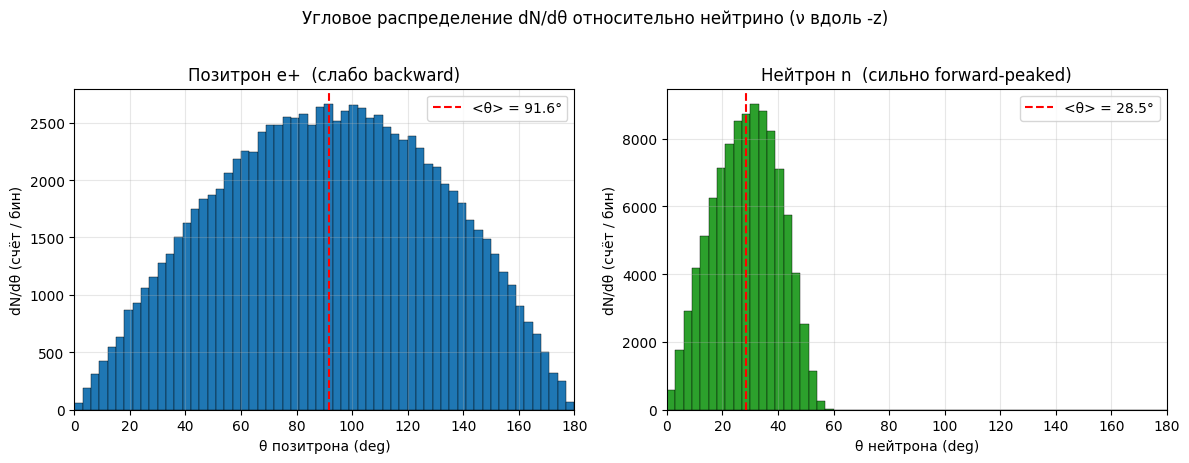

In [5]:
# ===== Угловое распределение dN/dθ позитрона и нейтрона =====
# Угол θ отсчитывается относительно направления антинейтрино (ν летит вдоль -z).
theta_bins = np.linspace(0, 180, 61)  # 60 бинов по 3°

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Позитрон ---
axes[0].hist(kin["thetaE_deg"], bins=theta_bins, color="#1f77b4",
             edgecolor="black", linewidth=0.3)
mean_te = kin["thetaE_deg"].mean()
axes[0].axvline(mean_te, color="red", ls="--", lw=1.5, label=f"<θ> = {mean_te:.1f}°")
axes[0].set_xlabel("θ позитрона (deg)")
axes[0].set_ylabel("dN/dθ (счёт / бин)")
axes[0].set_title("Позитрон e+  (слабо backward)")
axes[0].set_xlim(0, 180)
axes[0].grid(alpha=0.3)
axes[0].legend()

# --- Нейтрон ---
axes[1].hist(kin["thetaN_deg"], bins=theta_bins, color="#2ca02c",
             edgecolor="black", linewidth=0.3)
mean_tn = kin["thetaN_deg"].mean()
axes[1].axvline(mean_tn, color="red", ls="--", lw=1.5, label=f"<θ> = {mean_tn:.1f}°")
axes[1].set_xlabel("θ нейтрона (deg)")
axes[1].set_ylabel("dN/dθ (счёт / бин)")
axes[1].set_title("Нейтрон n  (сильно forward-peaked)")
axes[1].set_xlim(0, 180)
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle("Угловое распределение dN/dθ относительно нейтрино (ν вдоль -z)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "angular_dNdtheta.png"), dpi=150, bbox_inches="tight")
plt.show()

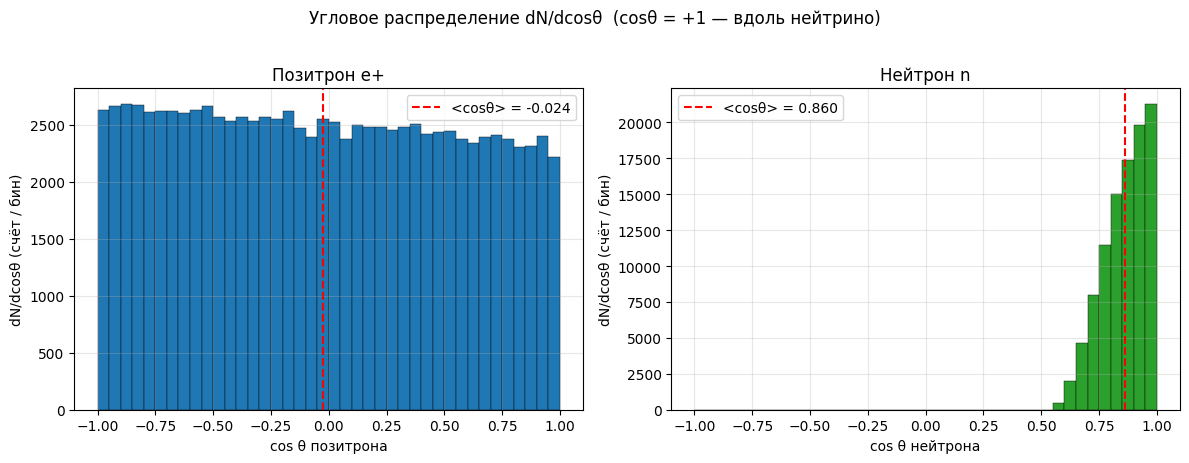

In [6]:
# ===== То же распределение в естественной переменной cosθ =====
# cosθ = +1 — частица летит вдоль нейтрино (-z), cosθ = -1 — против.
cos_bins = np.linspace(-1, 1, 41)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(kin["cosThetaE"], bins=cos_bins, color="#1f77b4",
             edgecolor="black", linewidth=0.3)
axes[0].axvline(kin["cosThetaE"].mean(), color="red", ls="--", lw=1.5,
                label=f"<cosθ> = {kin['cosThetaE'].mean():.3f}")
axes[0].set_xlabel("cos θ позитрона")
axes[0].set_ylabel("dN/dcosθ (счёт / бин)")
axes[0].set_title("Позитрон e+")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].hist(kin["cosThetaN"], bins=cos_bins, color="#2ca02c",
             edgecolor="black", linewidth=0.3)
axes[1].axvline(kin["cosThetaN"].mean(), color="red", ls="--", lw=1.5,
                label=f"<cosθ> = {kin['cosThetaN'].mean():.3f}")
axes[1].set_xlabel("cos θ нейтрона")
axes[1].set_ylabel("dN/dcosθ (счёт / бин)")
axes[1].set_title("Нейтрон n")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle("Угловое распределение dN/dcosθ  (cosθ = +1 — вдоль нейтрино)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "angular_dNdcos.png"), dpi=150, bbox_inches="tight")
plt.show()

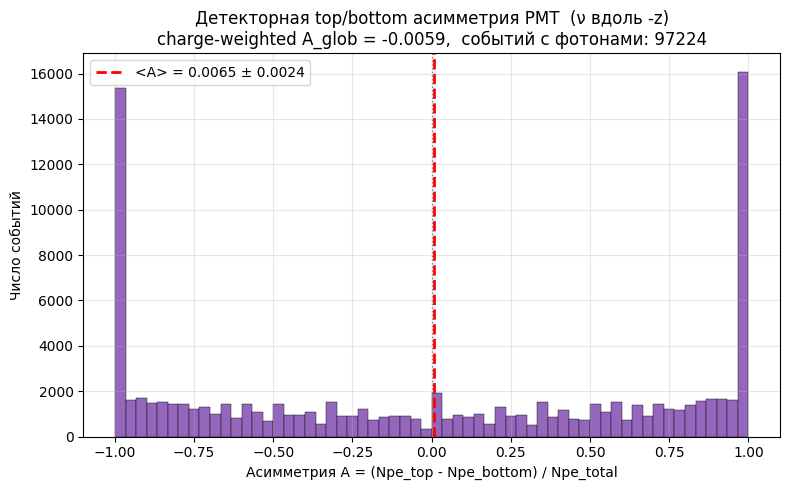

Средняя по событиям <A>      = 0.0065 ± 0.0024
Charge-weighted глобальная A = -0.0059
Событий с Npe_total>0        = 97224 из 100000


In [7]:
# ===== Детекторная top/bottom PMT-асимметрия =====
# A = (Npe_top - Npe_bottom) / Npe_total.  Нейтрино летит вниз (-z).
pe_hit = pe[pe["Npe_total"] > 0].copy()
A = (pe_hit["Npe_top"] - pe_hit["Npe_bottom"]) / pe_hit["Npe_total"]

mean_A = A.mean()
err_A = A.std(ddof=1) / np.sqrt(len(A))
# Глобальная (charge-weighted) асимметрия по всей статистике
A_glob = (pe_hit["Npe_top"].sum() - pe_hit["Npe_bottom"].sum()) / pe_hit["Npe_total"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(A, bins=np.linspace(-1, 1, 61), color="#9467bd",
        edgecolor="black", linewidth=0.3)
ax.axvline(mean_A, color="red", ls="--", lw=2, label=f"<A> = {mean_A:.4f} ± {err_A:.4f}")
ax.axvline(0.0, color="gray", ls=":", lw=1)
ax.set_xlabel("Асимметрия A = (Npe_top - Npe_bottom) / Npe_total")
ax.set_ylabel("Число событий")
ax.set_title("Детекторная top/bottom асимметрия PMT  (ν вдоль -z)\n"
             f"charge-weighted A_glob = {A_glob:.4f},  событий с фотонами: {len(A)}")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "pmt_topbottom_asymmetry.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Средняя по событиям <A>      = {mean_A:.4f} ± {err_A:.4f}")
print(f"Charge-weighted глобальная A = {A_glob:.4f}")
print(f"Событий с Npe_total>0        = {len(A)} из {len(pe)}")

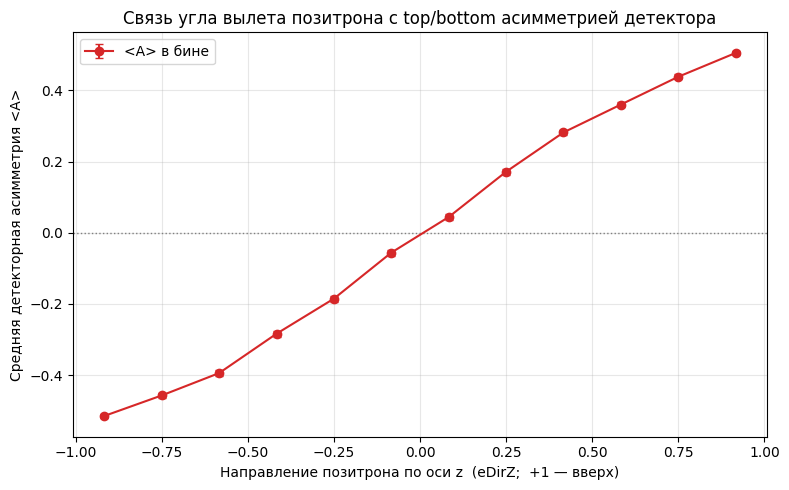

Корреляция Пирсона (eDirZ, детекторная A) = 0.4589


In [8]:
# ===== Связь кинематики и детектора: <A> vs направление позитрона по оси z =====
# eDirZ > 0  -> позитрон летит вверх (к верхним PMT);  ν летит вниз (-z).
# Здесь видно, как угловая корреляция позитрона проявляется в детекторной асимметрии.
merged = pd.merge(kin[["event_id", "eDirZ", "cosThetaE"]],
                  pe[["event_id", "Npe_top", "Npe_bottom", "Npe_total"]],
                  on="event_id")
merged = merged[merged["Npe_total"] > 0].copy()
merged["A"] = (merged["Npe_top"] - merged["Npe_bottom"]) / merged["Npe_total"]

n_zbins = 12
z_edges = np.linspace(-1, 1, n_zbins + 1)
z_cent = 0.5 * (z_edges[:-1] + z_edges[1:])
idx = np.clip(np.digitize(merged["eDirZ"].to_numpy(), z_edges) - 1, 0, n_zbins - 1)

mean_per_bin = np.full(n_zbins, np.nan)
err_per_bin = np.full(n_zbins, np.nan)
A_arr = merged["A"].to_numpy()
for b in range(n_zbins):
    sel = A_arr[idx == b]
    if sel.size > 0:
        mean_per_bin[b] = sel.mean()
        err_per_bin[b] = sel.std(ddof=1) / np.sqrt(sel.size) if sel.size > 1 else 0.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(z_cent, mean_per_bin, yerr=err_per_bin, fmt="o-", color="#d62728",
            capsize=3, label="<A> в бине")
ax.axhline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("Направление позитрона по оси z  (eDirZ;  +1 — вверх)")
ax.set_ylabel("Средняя детекторная асимметрия <A>")
ax.set_title("Связь угла вылета позитрона с top/bottom асимметрией детектора")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "asym_vs_positron_dir.png"), dpi=150, bbox_inches="tight")
plt.show()

corr = np.corrcoef(merged["eDirZ"], merged["A"])[0, 1]
print(f"Корреляция Пирсона (eDirZ, детекторная A) = {corr:.4f}")